##**Uber Fare Prediction**

# 1. Introduction
Refer to the point 1 from Detailed Breakdown section on Teachable

In [ ]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
import xgboost as xgb

RANDOM_STATE = 42
df = pd.read_csv('/content/uber.csv')


print('Initial shape:', df.shape)
df.head()

Initial shape: (200000, 9)


,Unnamed: 0,key,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
0,24238194,2015-05-07 19:52:06.0000003,7.5,2015-05-07 19:52:06 UTC,-73.999817,40.738354,-73.999512,40.723217,1
1,27835199,2009-07-17 20:04:56.0000002,7.7,2009-07-17 20:04:56 UTC,-73.994355,40.728225,-73.994710,40.750325,1
2,44984355,2009-08-24 21:45:00.00000061,12.9,2009-08-24 21:45:00 UTC,-74.005043,40.740770,-73.962565,40.772647,1
3,25894730,2009-06-26 08:22:21.0000001,5.3,2009-06-26 08:22:21 UTC,-73.976124,40.790844,-73.965316,40.803349,3
4,17610152,2014-08-28 17:47:00.000000188,16.0,2014-08-28 17:47:00 UTC,-73.925023,40.744085,-73.973082,40.761247,5


##**Data Cleaning & Pre-clean Analysis**
https://sklab.io/courses/datascience-old/lectures/64132445


Missing values per column:
Unnamed: 0           0
key                  0
fare_amount          0
pickup_datetime      0
pickup_longitude     0
pickup_latitude      0
dropoff_longitude    1
dropoff_latitude     1
passenger_count      0
dtype: int64


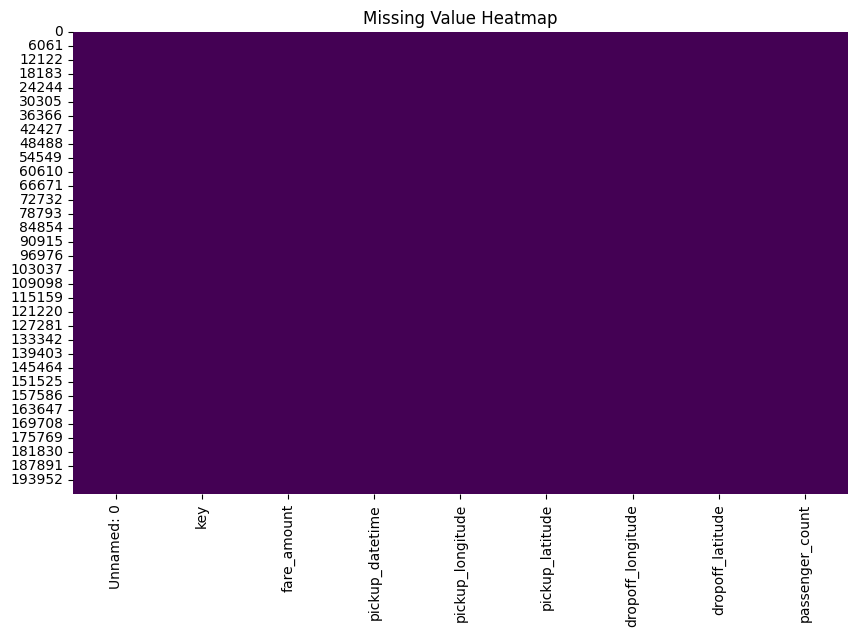

Analyzing outliers before cleaning...


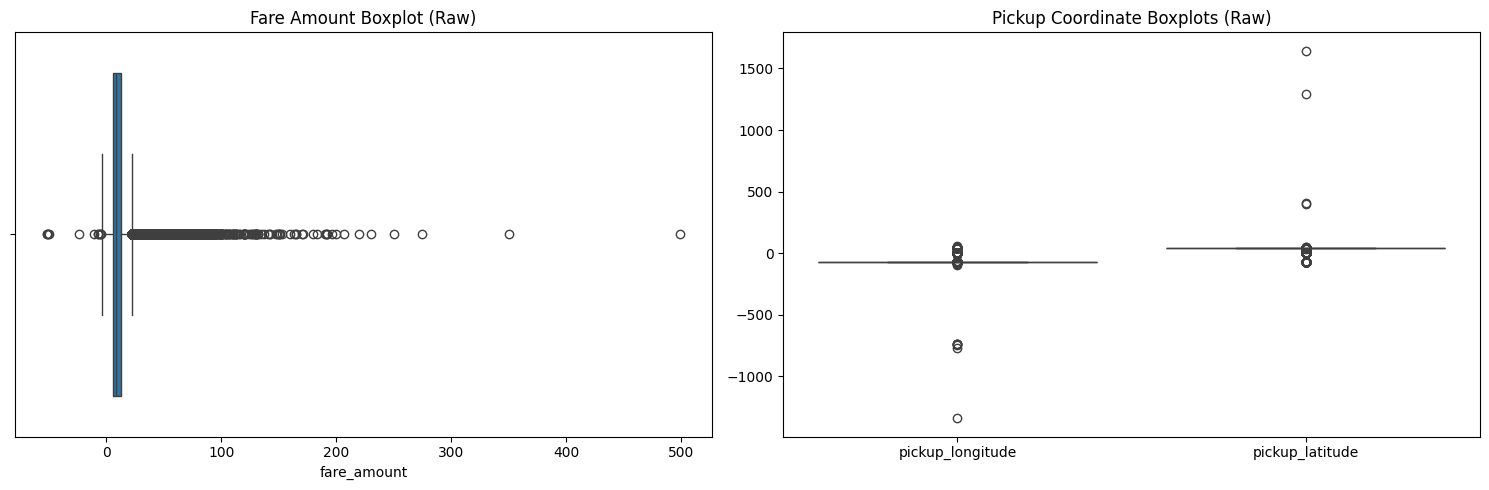

Shape after cleaning: (195787, 9)
Rows dropped: 4213 (2.11%)


,Unnamed: 0,key,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
0,24238194,2015-05-07 19:52:06.0000003,7.5,2015-05-07 19:52:06 UTC,-73.999817,40.738354,-73.999512,40.723217,1
1,27835199,2009-07-17 20:04:56.0000002,7.7,2009-07-17 20:04:56 UTC,-73.994355,40.728225,-73.994710,40.750325,1
2,44984355,2009-08-24 21:45:00.00000061,12.9,2009-08-24 21:45:00 UTC,-74.005043,40.740770,-73.962565,40.772647,1
3,25894730,2009-06-26 08:22:21.0000001,5.3,2009-06-26 08:22:21 UTC,-73.976124,40.790844,-73.965316,40.803349,3
4,17610152,2014-08-28 17:47:00.000000188,16.0,2014-08-28 17:47:00 UTC,-73.925023,40.744085,-73.973082,40.761247,5


In [ ]:
# 1. Missing Value Analysis
print("Missing values per column:")
print(df.isnull().sum())

# Visual missingness (using seaborn heatmap)
plt.figure(figsize=(10, 6))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis')
plt.title('Missing Value Heatmap')
plt.show()

rows_before = df.shape[0]

# 2. Outlier Detection (Before Cleaning)
print("Analyzing outliers before cleaning...")
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Boxplot for Fare Amount
if 'fare_amount' in df.columns:
    sns.boxplot(x=df['fare_amount'], ax=axes[0])
    axes[0].set_title('Fare Amount Boxplot (Raw)')

# Boxplot for Coordinates (just pickup to keep it simple)
if {'pickup_longitude', 'pickup_latitude'}.issubset(df.columns):
    sns.boxplot(data=df[['pickup_longitude', 'pickup_latitude']], ax=axes[1])
    axes[1].set_title('Pickup Coordinate Boxplots (Raw)')

plt.tight_layout()
plt.show()

# Step 1: Remove rows with any missing values
df = df.dropna()

# Step 2: Remove trips with invalid coordinates
coord_cols = ['pickup_longitude','pickup_latitude','dropoff_longitude','dropoff_latitude']
for c in coord_cols:
    if c in df.columns:
        df = df[df[c] != 0]

# Step 3: Remove trips with zero or negative fares
if 'fare_amount' in df.columns:
    df = df[df['fare_amount'] > 0]

# Step 4: Filter to NYC geographic boundaries
NYC_BOUNDS = {
    'lon_min': -75, 'lon_max': -72,
    'lat_min':  40, 'lat_max':  42
}
if set(coord_cols).issubset(df.columns):
    df = df[
        (df['pickup_longitude'].between(NYC_BOUNDS['lon_min'], NYC_BOUNDS['lon_max'])) &
        (df['dropoff_longitude'].between(NYC_BOUNDS['lon_min'], NYC_BOUNDS['lon_max'])) &
        (df['pickup_latitude'].between(NYC_BOUNDS['lat_min'], NYC_BOUNDS['lat_max'])) &
        (df['dropoff_latitude'].between(NYC_BOUNDS['lat_min'], NYC_BOUNDS['lat_max']))
    ]

# Data Quality Checks (Duplicates)
dupes = df.duplicated().sum()
if dupes > 0:
    print(f"Detected {dupes} duplicate rows. Dropping them.")
    df = df.drop_duplicates()

# Report dropped rows
rows_after = df.shape[0]
print(f'Shape after cleaning: {df.shape}')
print(f'Rows dropped: {rows_before - rows_after} ({((rows_before - rows_after)/rows_before)*100:.2f}%)')

df.head()

* Only two columns had missing values, with just one missing entry each.
* Heatmap confirms missingness is almost nonexistent.
* Fare amount shows many extreme outliers, including very high fares.
* Pickup coordinates include unrealistic values far outside NYC.
* Rows with missing data were removed.
* Rows with zero or invalid coordinates were dropped.
* Trips with zero or negative fares were removed.
* Data was filtered to NYC latitude/longitude boundaries.
* Duplicate rows were removed if present.
* About 2.11% of rows were dropped, leaving 195,787 cleaned rows.

## **FEATURE ENGINEERING**

https://sklab.io/courses/datascience-old/lectures/64132516

In [ ]:
def haversine_distance(lat1, lon1, lat2, lon2):
    """
    Calculate the great circle distance between two points on Earth.
    """
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])

    dlon = lon2 - lon1
    dlat = lat2 - lat1

    # Apply Haversine formula
    a = np.sin(dlat/2.0)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2.0)**2
    c = 2 * np.arcsin(np.sqrt(a))
    r = 6371.0
    return c * r

# Extract time-based features
if 'pickup_datetime' in df.columns:
    df['pickup_datetime'] = pd.to_datetime(df['pickup_datetime'], errors='coerce')
    df = df.dropna(subset=['pickup_datetime'])

    df['hour']    = df['pickup_datetime'].dt.hour
    df['day']     = df['pickup_datetime'].dt.day
    df['month']   = df['pickup_datetime'].dt.month
    df['weekday'] = df['pickup_datetime'].dt.weekday
    df['year']    = df['pickup_datetime'].dt.year
else:
    for col in ['hour','day','month','weekday','year']:
        df[col] = 0

# Calculate the distance feature
if {'pickup_latitude','pickup_longitude','dropoff_latitude','dropoff_longitude'}.issubset(df.columns):
    df['distance_km'] = haversine_distance(
        df['pickup_latitude'].values,
        df['pickup_longitude'].values,
        df['dropoff_latitude'].values,
        df['dropoff_longitude'].values
    )
else:
    df['distance_km'] = 0.0

# logical Consistency Check: Distance-Fare Mismatch
zero_dist_trips = df[(df['distance_km'] == 0) & (df['fare_amount'] > 0)]
print(f"Trips with 0 distance but positive fare: {len(zero_dist_trips)}")

df['is_rush_hour'] = (
    (df['weekday'] < 5) &
    (
        (df['hour'].between(7,9)) |
        (df['hour'].between(16,19))
    )
).astype(int)

df[['fare_amount','distance_km','hour','weekday','is_rush_hour']].head()

Trips with 0 distance but positive fare: 2038


,fare_amount,distance_km,hour,weekday,is_rush_hour
0,7.5,1.683323,19,3,1
1,7.7,2.457590,20,4,0
2,12.9,5.036377,21,0,0
3,5.3,1.661683,8,4,1
4,16.0,4.475450,17,3,1


* Distance is computed using the Haversine formula based on pickup and dropoff
coordinates.
* Time-based features (hour, day, month, weekday, year) are extracted from pickup_datetime.
* A new distance_km column is added to the dataframe.
* A logical check identifies trips with zero distance but a positive fare (found 2,038 such trips).
* A is_rush_hour feature is created based on weekday and time ranges (7–9 AM, 4–7 PM).
* The preview shows fare, computed distance, hour, weekday, and rush-hour flag.

---

## **EXPLORATORY DATA ANALYSIS (EDA)**

https://sklab.io/courses/datascience-old/lectures/64132525

Generating Univariate Visualizations...


/tmp/ipython-input-168779244.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df['hour'], ax=axes[1,0], palette='viridis')
/tmp/ipython-input-168779244.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df['weekday_name'], order=order, ax=axes[1,1], palette='magma')


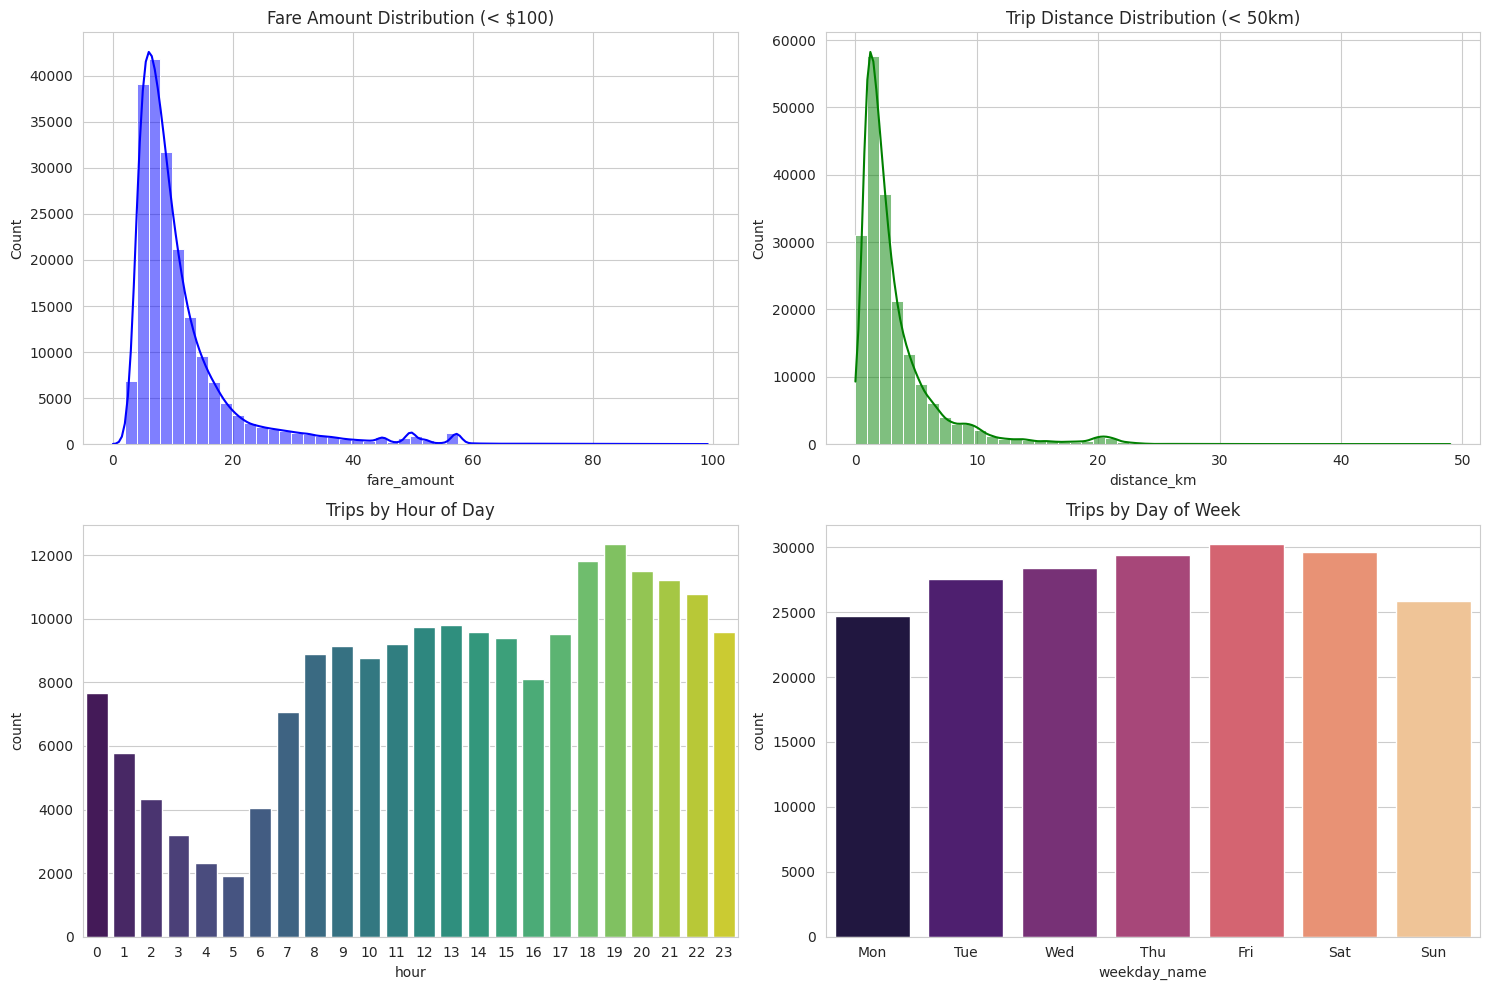

Generating Bivariate Visualizations...


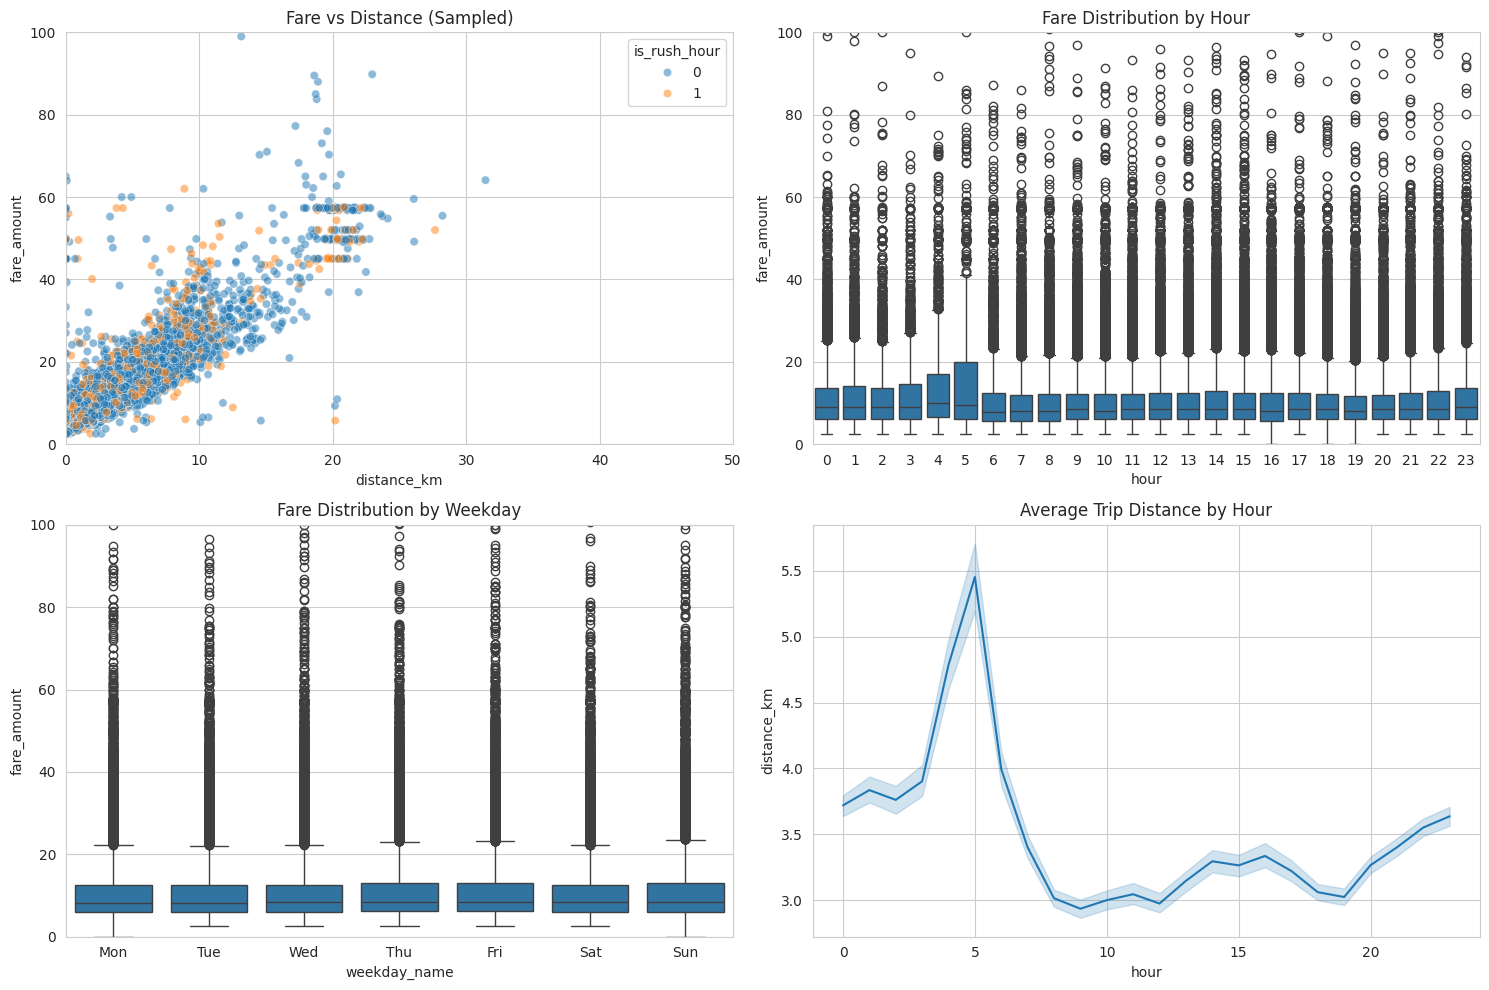

Generating Geographic Density Map...


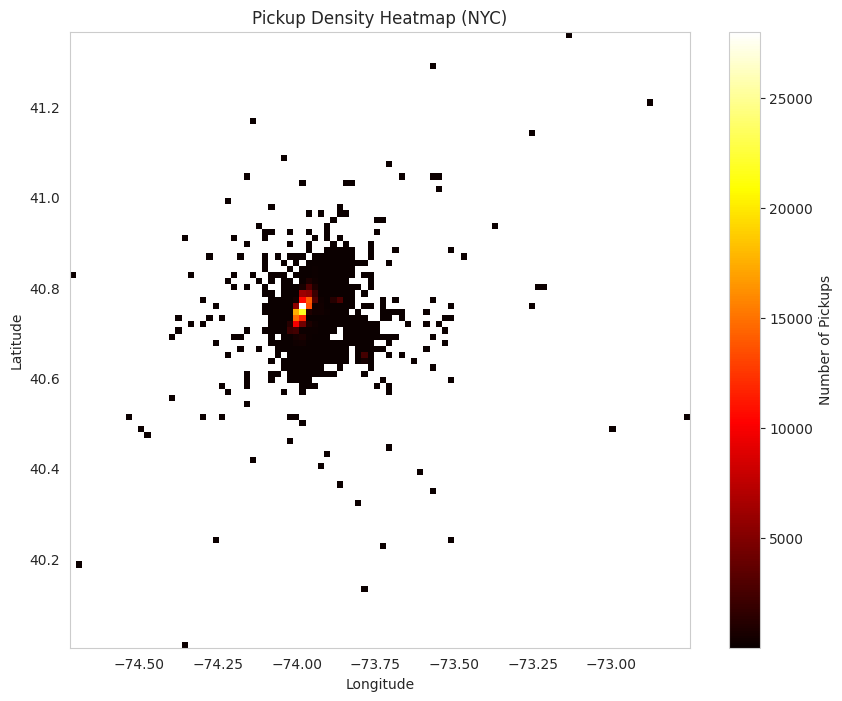

Generating Correlation Matrix...


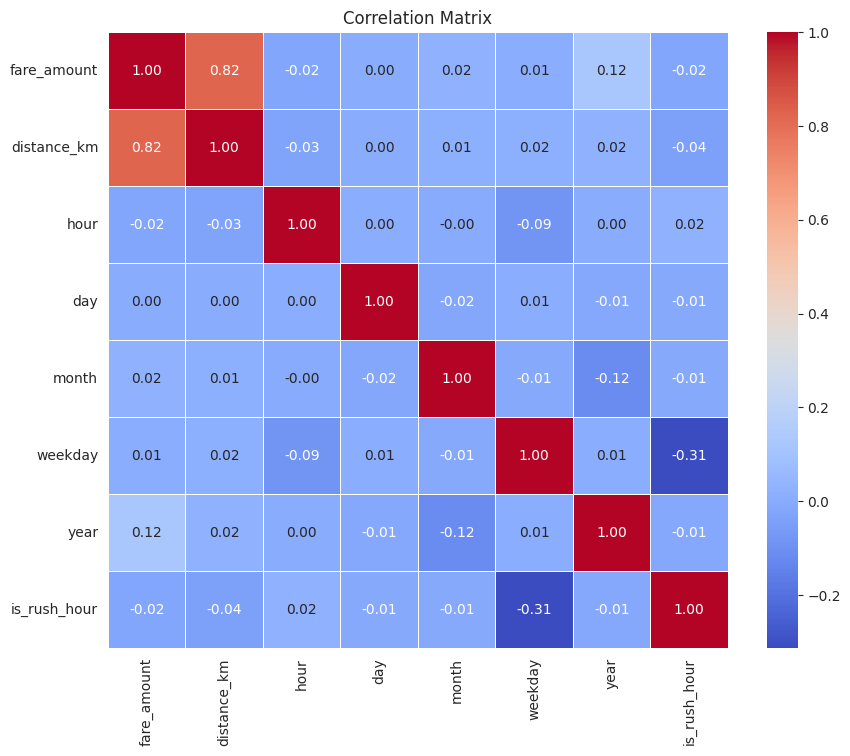

Generating Pairplot (Sampled)...


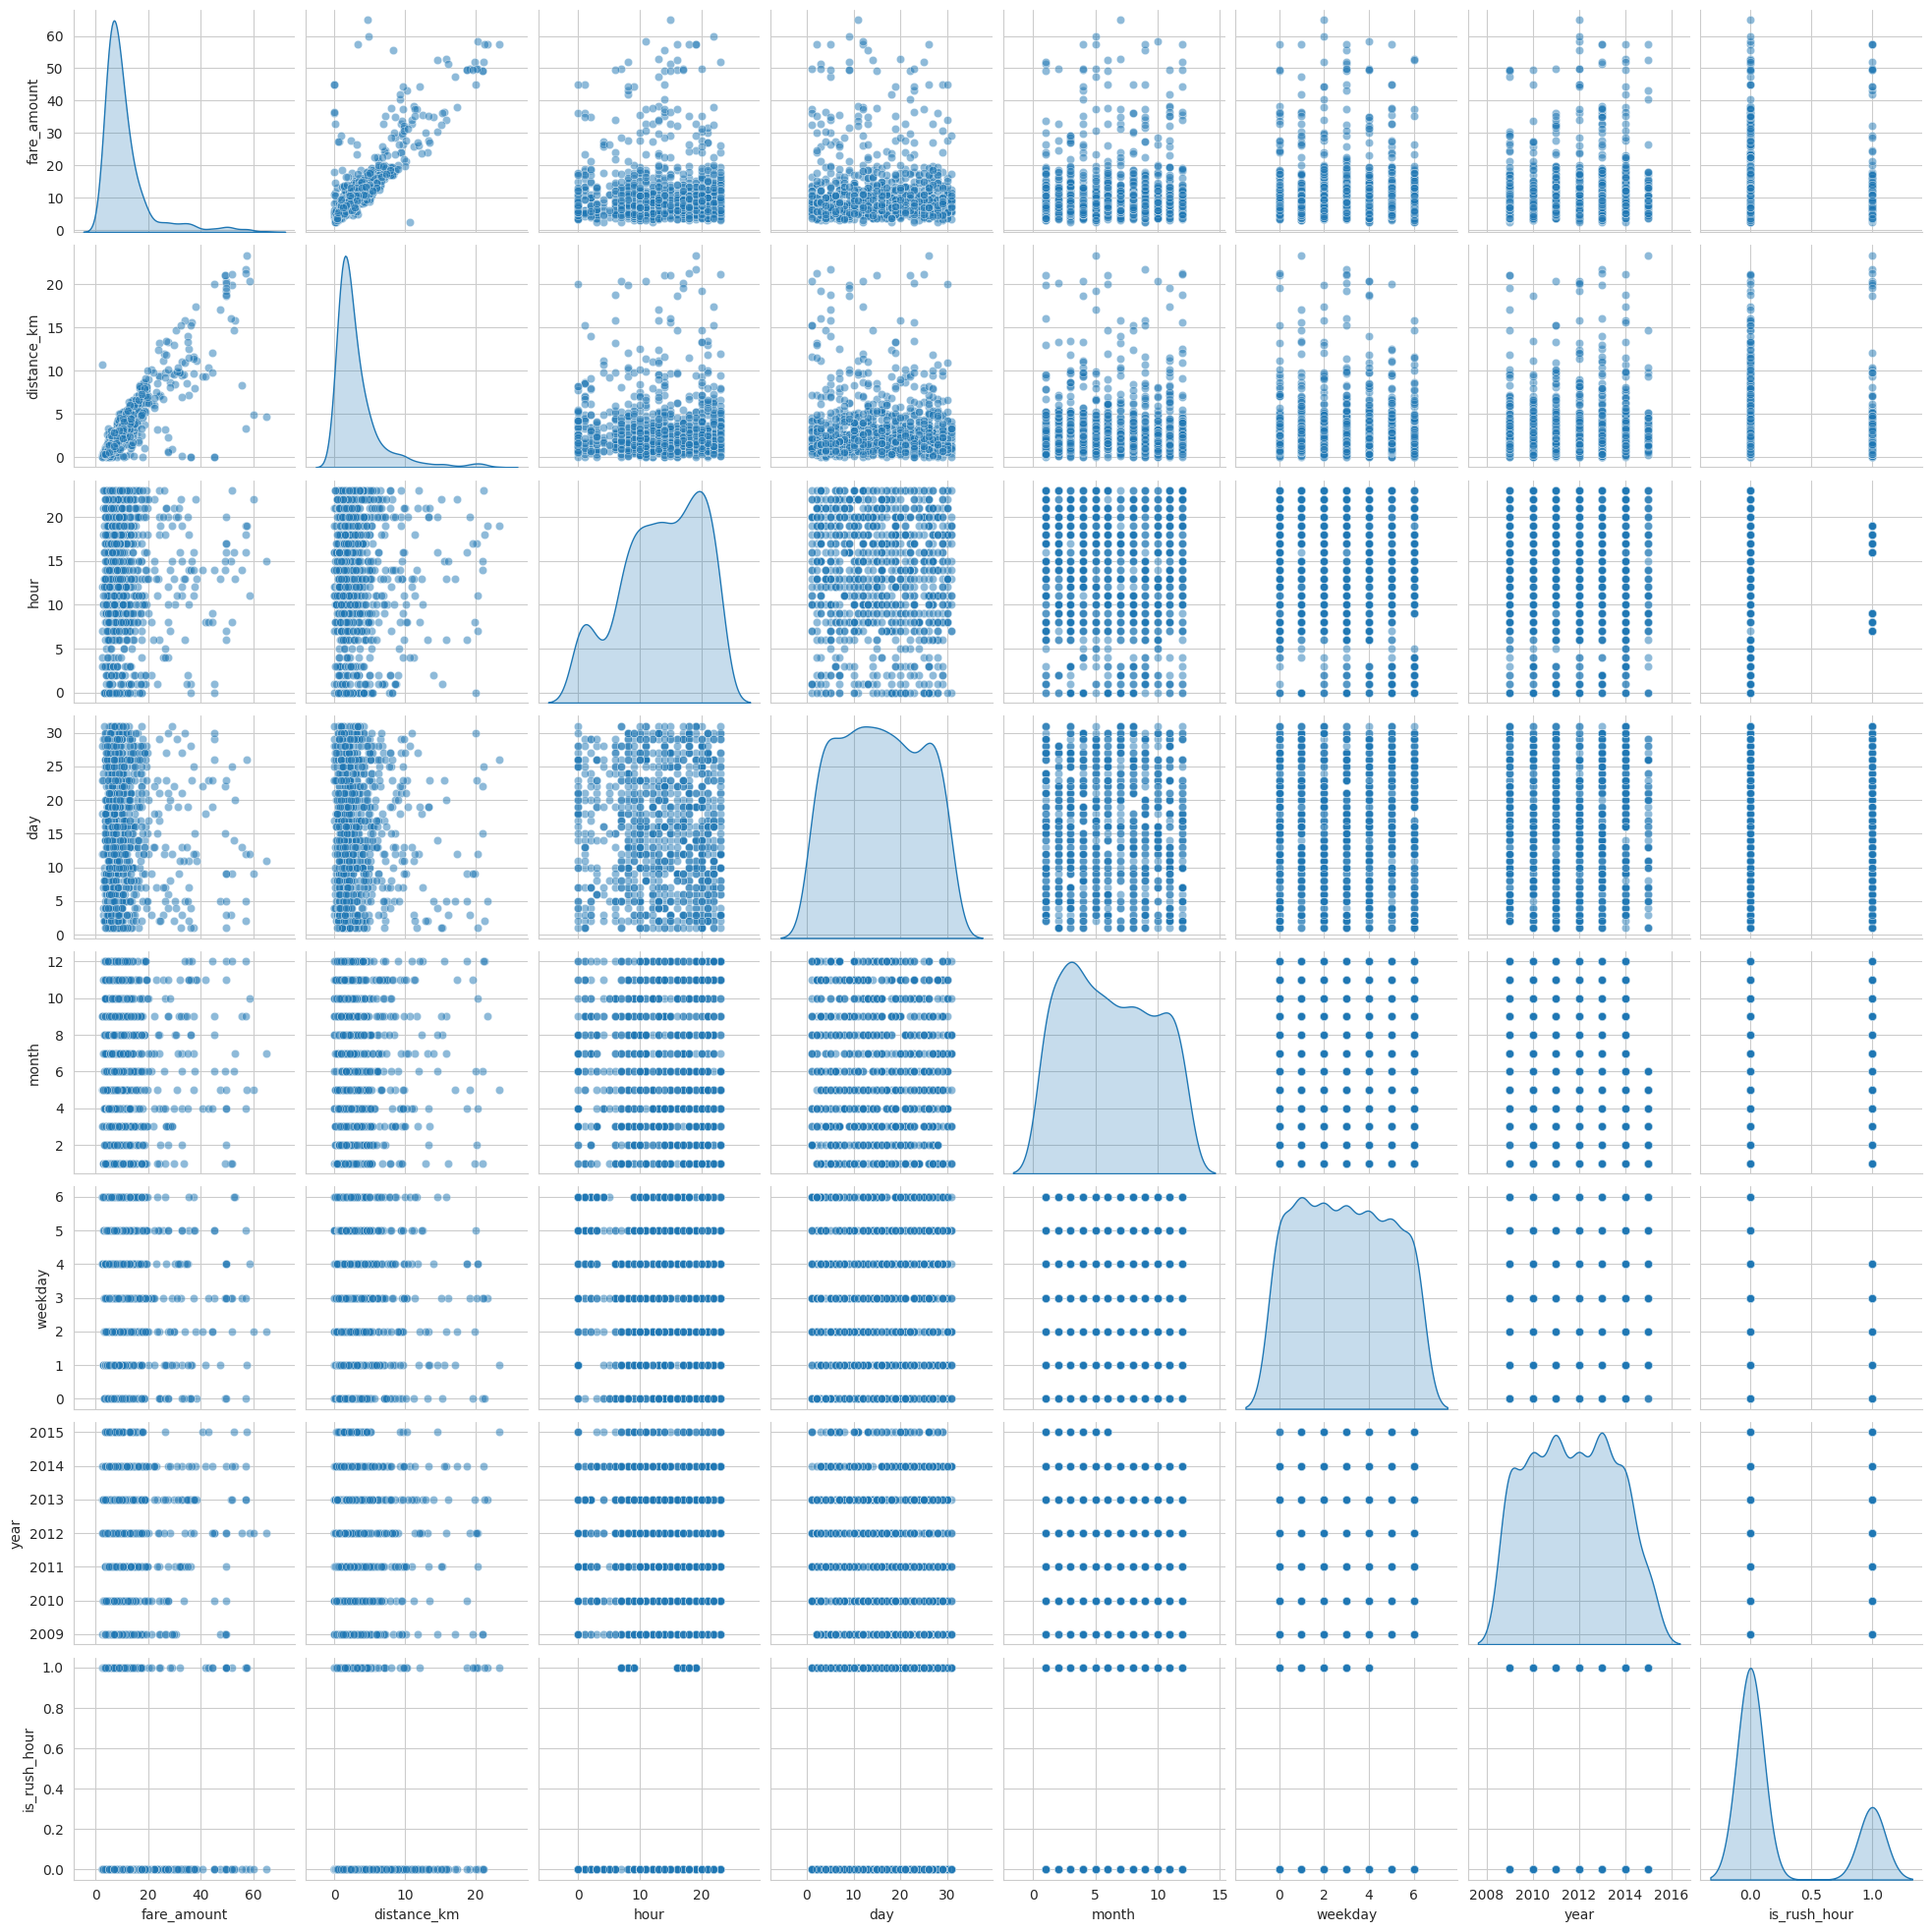

Generating Time Series Trends...


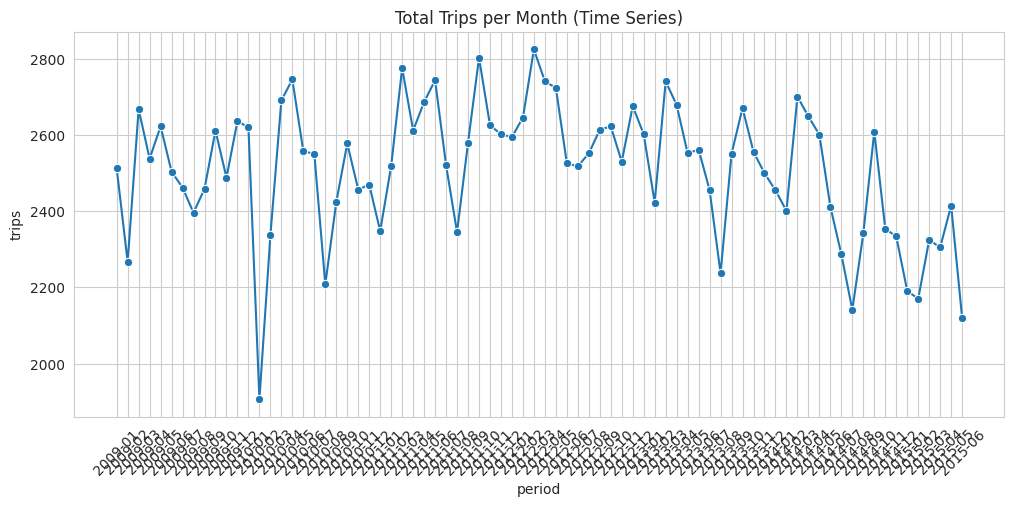

Top correlations with Fare Amount:
fare_amount     1.000000
distance_km     0.822559
year            0.118704
month           0.024041
weekday         0.006525
day             0.000471
hour           -0.020838
is_rush_hour   -0.021045
Name: fare_amount, dtype: float64


In [ ]:
sns.set_style("whitegrid")

# Univariate Analysis
print("Generating Univariate Visualizations...")
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Fare Distribution (Log scale option often helps, but we stick to range < 100 for clarity)
sns.histplot(df[df['fare_amount'] < 100]['fare_amount'], bins=50, kde=True, ax=axes[0,0], color='blue')
axes[0,0].set_title('Fare Amount Distribution (< $100)')

# Distance Distribution
sns.histplot(df[df['distance_km'] < 50]['distance_km'], bins=50, kde=True, ax=axes[0,1], color='green')
axes[0,1].set_title('Trip Distance Distribution (< 50km)')

# Pickup Hour Distribution
sns.countplot(x=df['hour'], ax=axes[1,0], palette='viridis')
axes[1,0].set_title('Trips by Hour of Day')

# Pickup Day of Week
day_map = {0:'Mon', 1:'Tue', 2:'Wed', 3:'Thu', 4:'Fri', 5:'Sat', 6:'Sun'}
df['weekday_name'] = df['weekday'].map(day_map)
order = ['Mon','Tue','Wed','Thu','Fri','Sat','Sun']
sns.countplot(x=df['weekday_name'], order=order, ax=axes[1,1], palette='magma')
axes[1,1].set_title('Trips by Day of Week')

plt.tight_layout()
plt.show()

# Bivariate Analysis & Feature Interactions
print("Generating Bivariate Visualizations...")
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Fare vs Distance (Scatter) - The most important relationship
subset = df.sample(min(len(df), 10000))
sns.scatterplot(x=subset['distance_km'], y=subset['fare_amount'], hue=subset['is_rush_hour'], alpha=0.5, ax=axes[0,0])
axes[0,0].set_title('Fare vs Distance (Sampled)')
axes[0,0].set_xlim(0, 50)
axes[0,0].set_ylim(0, 100)

# Fare vs Hour (Boxplot to see price variance by time)
sns.boxplot(x=df['hour'], y=df['fare_amount'], ax=axes[0,1])
axes[0,1].set_title('Fare Distribution by Hour')
axes[0,1].set_ylim(0, 100)

# Fare vs Weekday
sns.boxplot(x=df['weekday_name'], y=df['fare_amount'], order=order, ax=axes[1,0])
axes[1,0].set_title('Fare Distribution by Weekday')
axes[1,0].set_ylim(0, 100)

# Distance vs Hour (When do people take long trips?)
sns.lineplot(x=df['hour'], y=df['distance_km'], ax=axes[1,1])
axes[1,1].set_title('Average Trip Distance by Hour')

plt.tight_layout()
plt.show()

# Geographic EDA (Density Heatmap)
print("Generating Geographic Density Map...")
plt.figure(figsize=(10, 8))
plt.hist2d(df['pickup_longitude'], df['pickup_latitude'], bins=100, cmap='hot', cmin=1)
plt.colorbar(label='Number of Pickups')
plt.title('Pickup Density Heatmap (NYC)')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.grid(False)
plt.show()

# Multivariate Analysis & Correlation Matrix
print("Generating Correlation Matrix...")
plt.figure(figsize=(10, 8))
numeric_cols = ['fare_amount', 'distance_km', 'hour', 'day', 'month', 'weekday', 'year', 'is_rush_hour']
corr_matrix = df[numeric_cols].corr()

# Correlation Heatmap
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Matrix')
plt.show()

# Pairplot (Optional / Sampled)
print("Generating Pairplot (Sampled)...")
# Plotting a small subset to show interactions
pp_subset = df[numeric_cols].sample(min(len(df), 1000))
sns.pairplot(pp_subset, diag_kind='kde', plot_kws={'alpha': 0.5})
plt.show()

# Time Series EDA (Aggregated)
print("Generating Time Series Trends...")
monthly_trips = df.groupby(['year', 'month']).size().reset_index(name='trips')
monthly_trips['period'] = monthly_trips['year'].astype(str) + '-' + monthly_trips['month'].astype(str).str.zfill(2)
monthly_trips = monthly_trips.sort_values(['year', 'month'])

plt.figure(figsize=(12, 5))
sns.lineplot(x=monthly_trips['period'], y=monthly_trips['trips'], marker='o')
plt.xticks(rotation=45)
plt.title('Total Trips per Month (Time Series)')
plt.show()

# Print top correlations to confirm
print("Top correlations with Fare Amount:")
print(corr_matrix['fare_amount'].sort_values(ascending=False).head(10))

* Fare amounts are heavily right-skewed, with most fares under $20.
* Trip distances are also right-skewed, with most rides under ~5 km.
* Trip volume spikes during morning (8–10 AM) and evening (5–7 PM) hours.
* Late-night trips (midnight–5 AM) drop significantly in frequency.
* Weekdays have slightly higher trip counts than weekends.
* Scatterplot shows a clear positive relationship between distance and fare.
* Rush hour does not dramatically increase fares visually, but fares are slightly more variable.
* Fare distribution by hour is fairly stable, with outliers spread across all hours.
* Fare distribution by weekday is similar for all days, with weekends showing slightly higher variance.
* Average trip distance peaks around 5–6 AM, then declines during the day, rising again at night.
* Pickup density heatmap shows the highest concentration in Manhattan (expected pattern).
* Correlation matrix shows:
      Distance and fare have a strong positive correlation (~0.82).
      Other temporal features have minimal correlation with fare.
* Pairplot confirms the dominance of distance as the main driver of fare.
* Monthly trip counts fluctuate but generally stay between 2300–2700 per month.
* No strong seasonality observed in monthly trends; variation appears random.

---

## **TRAIN/TEST SPLIT**

https://sklab.io/courses/datascience-old/lectures/64132528

In [ ]:

TARGET = 'fare_amount'

feature_cols = ['distance_km','hour','day','month','weekday','year','is_rush_hour']

if 'passenger_count' in df.columns and df['passenger_count'].notna().any():
    feature_cols.append('passenger_count')

X = df[feature_cols].copy()
y = df[TARGET].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=RANDOM_STATE
)

X_train.shape, X_test.shape

((156629, 8), (39158, 8))

---

## **MODELING**

https://sklab.io/courses/datascience-old/lectures/64132533

In [ ]:
lr = LinearRegression()
lr.fit(X_train, y_train)
pred_lr = lr.predict(X_test)

rmse_lr = float(np.sqrt(mean_squared_error(y_test, pred_lr)))
r2_lr   = float(r2_score(y_test, pred_lr))

print(f'Linear Regression -> RMSE: {rmse_lr:.4f}, R2: {r2_lr:.4f}')


rf = RandomForestRegressor(
    n_estimators=150,      # Number of trees (more trees = better but slower)
    max_depth=None,        # No limit on tree depth (trees can be as deep as needed)
    min_samples_leaf=1,    # Minimum samples required in a leaf node
    n_jobs=-1,             # Use all CPU cores for faster training
    random_state=RANDOM_STATE  # For reproducibility
)

rf.fit(X_train, y_train)

pred_rf = rf.predict(X_test)

rmse_rf = float(np.sqrt(mean_squared_error(y_test, pred_rf)))
r2_rf   = float(r2_score(y_test, pred_rf))

print(f'Random Forest -> RMSE: {rmse_rf:.4f}, R2: {r2_rf:.4f}')


results = {
    'Linear Regression': {'RMSE': rmse_lr, 'R2': r2_lr},
    'Random Forest': {'RMSE': rmse_rf, 'R2': r2_rf},
}


xgb_model = xgb.XGBRegressor(
    objective='reg:squarederror',
    n_estimators=300,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=RANDOM_STATE
)

xgb_model.fit(X_train, y_train)

pred_xgb = xgb_model.predict(X_test)

rmse_xgb = float(np.sqrt(mean_squared_error(y_test, pred_xgb)))
r2_xgb   = float(r2_score(y_test, pred_xgb))

print(f'XGBoost -> RMSE: {rmse_xgb:.4f}, R2: {r2_xgb:.4f}')

results['XGBoost'] = {'RMSE': rmse_xgb, 'R2': r2_xgb}

results

Linear Regression -> RMSE: 5.0760, R2: 0.7201
Random Forest -> RMSE: 4.4892, R2: 0.7811
XGBoost -> RMSE: 4.6103, R2: 0.7691


{'Linear Regression': {'RMSE': 5.076027648848429, 'R2': 0.7200917565928285},
 'Random Forest': {'RMSE': 4.489206101131779, 'R2': 0.7810692223249968},
 'XGBoost': {'RMSE': 4.610317378603756, 'R2': 0.7690971049564075}}

* Linear Regression performs the worst among the three, with the highest RMSE and lowest R².
* Random Forest performs the best overall, giving the lowest RMSE (~4.49) and highest R² (~0.78).
* XGBoost performs slightly worse than Random Forest but still better than Linear Regression.
* Nonlinear models (RF, XGBoost) capture more complex relationships in fare prediction than Linear Regression.
* Distance is likely the dominant feature, and tree-based models leverage nonlinear interactions more effectively.

---

## **EVALUATION & FEATURE IMPORTANCE**

https://sklab.io/courses/datascience-old/lectures/64132564


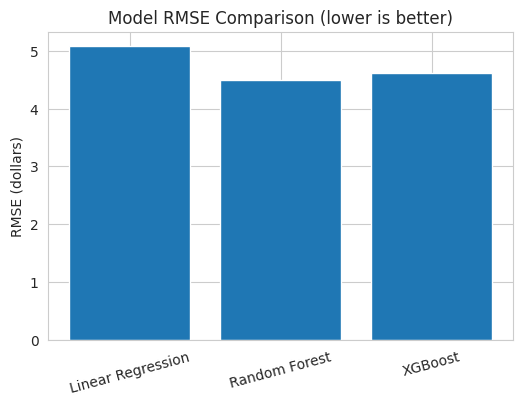

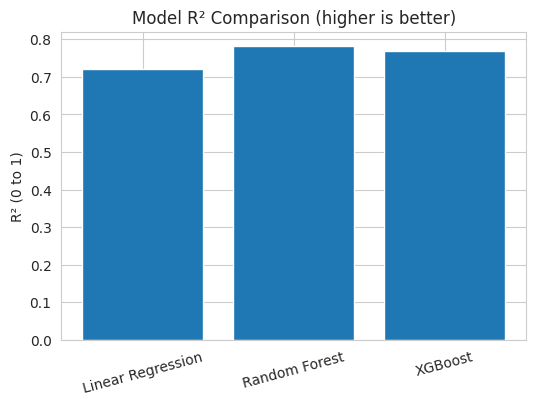

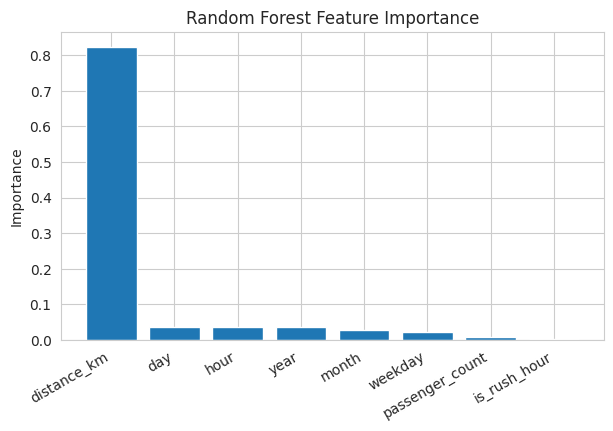

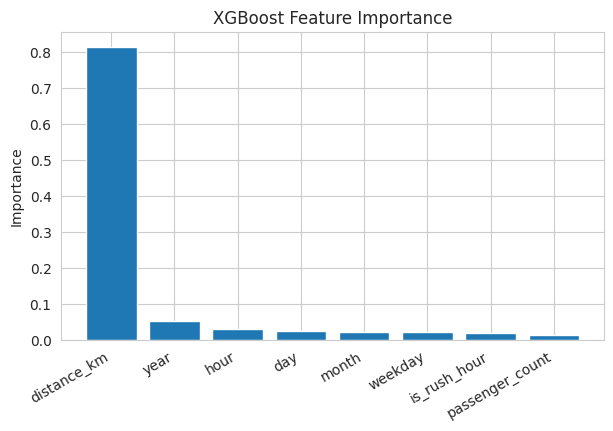

In [ ]:
labels = list(results.keys())
rmse_vals = [results[m]['RMSE'] for m in labels]
r2_vals   = [results[m]['R2'] for m in labels]


plt.figure(figsize=(6,4))
plt.bar(labels, rmse_vals)
plt.ylabel('RMSE (dollars)')
plt.title('Model RMSE Comparison (lower is better)')
plt.xticks(rotation=15)
plt.show()


plt.figure(figsize=(6,4))
plt.bar(labels, r2_vals)
plt.ylabel('R² (0 to 1)')
plt.title('Model R² Comparison (higher is better)')
plt.xticks(rotation=15)
plt.show()



def plot_feature_importance(model, feature_names, title):
    """
    Create a bar chart showing which features are most important for predictions.

    Parameters:
    - model: A trained tree-based model (Random Forest or XGBoost)
    - feature_names: List of feature names (e.g., ['distance_km', 'hour', ...])
    - title: Title for the plot

    How it works:
    1. Get feature importances from the model
    2. Sort features by importance (highest first)
    3. Create a bar chart showing importance values
    """

    importances = getattr(model, 'feature_importances_', None)

    if importances is None:
        print('No feature_importances_ on this model')
        return


    order = np.argsort(importances)[::-1]

    names = [feature_names[i] for i in order]
    vals  = [importances[i] for i in order]

    # Create the bar chart
    plt.figure(figsize=(7,4))
    plt.bar(names, vals)
    plt.title(title)
    plt.xticks(rotation=30, ha='right')
    plt.ylabel('Importance')
    plt.show()

# Plot feature importance for Random Forest
plot_feature_importance(rf, X.columns.tolist(), 'Random Forest Feature Importance')

# Plot feature importance for XGBoost
plot_feature_importance(xgb_model, X.columns.tolist(), 'XGBoost Feature Importance')

* Random Forest achieves the best performance (lowest RMSE, highest R²).
* XGBoost performs slightly worse than Random Forest but better than Linear Regression.
* Linear Regression performs the worst, indicating non-linear relationships in the data.
* Distance is overwhelmingly the most important feature for both Random Forest and XGBoost (≈80%+ importance).
* All time-based features (hour, day, month, weekday, year) have small but non-zero contributions.
* Passenger count and rush-hour indicators add minimal predictive value.
* Tree-based models leverage non-linear patterns and interactions, explaining their higher accuracy.

---

## **HYPERPARAMETER TUNING**

https://sklab.io/courses/datascience-old/lectures/64132572

In [ ]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [100, 200],      # Try 100 or 200 trees
    'max_depth': [None, 10, 20]      # Try unlimited depth, 10, or 20
}

small_rf = RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1)


grid = GridSearchCV(
    small_rf,
    param_grid,
    scoring='neg_root_mean_squared_error',
    cv=3,
    n_jobs=-1
)


grid.fit(X_train, y_train)


print('Best params:', grid.best_params_)


print('Best CV RMSE:', -grid.best_score_)


best_rf = grid.best_estimator_


pred_best = best_rf.predict(X_test)
rmse_best = float(np.sqrt(mean_squared_error(y_test, pred_best)))
r2_best   = float(r2_score(y_test, pred_best))


print(f'Tuned RF -> RMSE: {rmse_best:.4f}, R2: {r2_best:.4f}')

/usr/local/lib/python3.12/dist-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Best params: {'max_depth': 10, 'n_estimators': 200}
Best CV RMSE: 4.646759978453232
Tuned RF -> RMSE: 4.3213, R2: 0.7971


* Hyperparameter search selected max_depth = 10 and n_estimators = 200 as the best configuration.
* Best cross-validated RMSE improved to ≈ 4.65, confirming better generalization than the default model.
* Final tuned model achieved RMSE = 4.32, outperforming the untuned RF (4.49).
* Final tuned model reached R² = 0.797, a noticeable gain over the untuned RF (0.781).
* Tuning helped the model capture structure more efficiently without overfitting.

## **Key Takeaways:**

* Distance is by far the strongest predictor of fare, confirmed by both correlation (≈0.82) and feature-importance plots.
* Fare and distance distributions are right-skewed, with most trips being short and inexpensive.
* Trip frequency shows clear temporal patterns: strong morning and evening peaks, and low activity overnight.
* Tree-based models (Random Forest, XGBoost) outperform Linear Regression, indicating important nonlinear relationships.
* Tuned Random Forest achieves the best performance overall (RMSE ≈ 4.32, R² ≈ 0.80).
* Additional features such as hour, weekday, month, and passenger count contribute minimally to fare prediction.


**Congratulations!** You have built a Uber Fare Prediction system from scratch.